In [110]:
import os
import warnings

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from haversine import haversine_vector, Unit
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.models import Sequential

warnings.filterwarnings("ignore")


In [2]:
path = r"C:\Users\bhavy\Massachusetts Institute of Technology\Truck Parking Capstone - General\Truck Stop Finder 🚚⛽\\"
# path = r"C:\Users\samcl\Massachusetts Institute of Technology\Truck Parking Capstone - Truck Stop Finder 🚚⛽\\"

In [3]:
sensor_loc = pd.read_csv(path + r"5. Source & Refrence Files\sensor_loc.csv",
                         dtype={"station_id": 'str'})
state_map = pd.read_csv(path + r"5. Source & Refrence Files\State_mapping.csv")
model_stop = pd.read_excel("output_excel/Model_Stops_V3.xlsx")
traffic_df = pd.read_csv(path + r"4. Working Data Files\Traffic Files\Capstone_truck\merged_filtered_modified.csv")


In [4]:
sensor_loc.columns

Index(['Latitude', 'Longitude', 'Functional Class', 'State', 'Station Id'], dtype='object')

In [5]:
traffic_df["link_id"] = traffic_df["routeid"].astype("str") + "_" + traffic_df["beginpoint"].astype("str") + "_" + \
                        traffic_df["endpoint"].astype("str")
in_link = traffic_df[traffic_df["link_id"].isin(model_stop["link_id"].unique())][["link_id", "MID_LAT", "MID_LONG"]]

sensor_stops = pd.merge(in_link, sensor_loc, how="cross")

sensor_stops['distance_miles'] = haversine_vector(sensor_stops[['Latitude', 'Longitude']],
                                                  sensor_stops[['MID_LAT', 'MID_LONG']],
                                                  Unit.MILES
                                                  ) * 1.16

#Finding nearest road segment to every stop
idx = sensor_stops.groupby('link_id')['distance_miles'].idxmin()
nearest = sensor_stops.loc[idx].reset_index()
nearest = nearest[['Latitude', 'Longitude', 'Functional Class', 'State', 'Station Id', 'link_id']].copy()
nearest

,Latitude,Longitude,Functional Class,State,Station Id,link_id
0,26.916900,-82.011860,1R,FL,10350,01075000_12.0_12.1
1,33.480360,-81.931060,1R,SC,150,02010002000E_0.1_0.7
2,33.635350,-81.761950,1R,SC,115,02010002000E_10.06_11.22
3,33.635350,-81.761950,1R,SC,115,02010002000E_19.504_21.1
4,33.635350,-81.761950,1R,SC,115,02020000100N_13.6_13.7
...,...,...,...,...,...,...
722,32.358551,-86.252527,1U,AL,172,IN0000850000_6.095_6.195
723,32.730691,-85.293339,1R,AL,47,IN0000850000_64.678_64.714
724,32.730691,-85.293339,1R,AL,47,IN0000850000_70.576_70.595
725,32.866480,-85.166270,1R,GA,117,IN0000850000_78.631_78.73099999999998


In [6]:
# folder = path + r"5. Source & Refrence Files\2024_traffic_data"
# out_dir = os.path.join(path, r"5. Source & Refrence Files\2024_traffic_parquet")
# os.makedirs(out_dir, exist_ok=True)
#
# # build mapping dict ONCE from your state_map df
# state_dict = state_map.set_index("state_code")["State"].to_dict()
#
# id_var_col = [
#     'record_type', 'state_code', 'f_system', 'station_id', 'travel_dir',
#     'travel_lane', 'year_record', 'month_record', 'day_record',
#     'day_of_week', 'restrictions'
# ]
#
# part = 0
#
# for filename in os.listdir(folder):
#     file_path = os.path.join(folder, filename)
#
#     if not filename.lower().endswith(".zip"):
#         continue
#
#     print(f"Opening ZIP: {filename}")
#
#     with zipfile.ZipFile(file_path, 'r') as z:
#         for inner_name in z.namelist():
#             if inner_name.endswith("/"):
#                 continue
#
#             print(f"  Processing inside ZIP: {inner_name}")
#
#             with z.open(inner_name) as f:
#                 # Read CSV from inside the ZIP
#                 df = pd.read_csv(
#                     f,
#                     delimiter="|",
#                     low_memory=False  # avoids dtype warning at cost of some RAM, OK for chunk
#                     # You can also pass dtype={} here if you know them
#                 )
#
#                 # Melt wide hours columns into long format
#                 df = pd.melt(
#                     df,
#                     id_vars=id_var_col,
#                     var_name="hours",
#                     value_name="traffic"
#                 )
#
#                 # Add state_name via map instead of big merge later
#                 df["State"] = df["state_code"].map(state_dict)
#                 df["station_id"] = df["station_id"].astype(str)
#
#                 # Save this chunk to Parquet and drop from memory
#                 out_path = os.path.join(out_dir, f"traffic_part_{part}.parquet")
#                 df.to_parquet(out_path, index=False)
#                 # print(f"    → wrote {out_path}")
#
#                 del df
#                 part += 1
#
# print(f"Done. Wrote {part} parquet files to {out_dir}")


In [7]:
traffic_df = pd.DataFrame()

In [8]:
out_dir = os.path.join(path, r"5. Source & Refrence Files\2024_traffic_parquet")
traffic_parquet_glob = f"{out_dir}/traffic_part_*.parquet"

In [9]:
con = duckdb.connect()
con.register("sensor_loc", nearest)

In [10]:

out_dir = os.path.join(path, r"5. Source & Refrence Files\2024_traffic_parquet")
traffic_parquet_glob = f"{out_dir}/traffic_part_*.parquet"

In [11]:
sensor_loc

,Latitude,Longitude,Functional Class,State,Station Id
0,36.719788,-104.535744,4R,NM,WHIT01
1,40.485651,-74.426438,3U,NJ,W41024
2,40.892000,-74.223000,3U,NJ,W21035
3,39.771974,-74.901328,3U,NJ,W07140
4,39.944480,-74.095954,3U,NJ,W06108
...,...,...,...,...,...
8055,34.710839,-76.736897,4U,NC,0A1501
8056,35.551341,-82.731234,1U,NC,0A1003
8057,33.937646,-78.555950,7U,NC,0A0901
8058,35.946988,-82.004388,3R,NC,0A0501


In [12]:
con.execute(f"""
    CREATE OR REPLACE TABLE traffic_matched AS
    SELECT
        t.*,                           -- all columns from traffic
        s.*
    FROM read_parquet('{traffic_parquet_glob}') AS t
    LEFT JOIN sensor_loc AS s
      ON t.station_id = s."Station Id"
     AND t.State      = s.State
    WHERE s."Latitude" IS NOT NULL
""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [13]:
con.execute("""select *
               from traffic_matched limit 5""").df()

,record_type,state_code,f_system,station_id,travel_dir,travel_lane,year_record,month_record,day_record,day_of_week,restrictions,hours,traffic,State,Latitude,Longitude,Functional Class,State_1,Station Id,link_id
0,V,45,3R,2,1,1,2024,12,1,1,NaN,hour_00,48,SC,32.76263,-80.42998,3R,SC,2,15020001700N_16.68_16.78
1,V,45,3R,2,1,1,2024,12,2,2,NaN,hour_00,34,SC,32.76263,-80.42998,3R,SC,2,15020001700N_16.68_16.78
2,V,45,3R,2,1,1,2024,12,3,3,NaN,hour_00,20,SC,32.76263,-80.42998,3R,SC,2,15020001700N_16.68_16.78
3,V,45,3R,2,1,1,2024,12,4,4,NaN,hour_00,25,SC,32.76263,-80.42998,3R,SC,2,15020001700N_16.68_16.78
4,V,45,3R,2,1,1,2024,12,5,5,NaN,hour_00,20,SC,32.76263,-80.42998,3R,SC,2,15020001700N_16.68_16.78


In [14]:
con.execute(f"""
    CREATE OR REPLACE TABLE traffic_unmatched  AS
    SELECT
        t.*,                           -- all columns from traffic
        s.*
    FROM read_parquet('{traffic_parquet_glob}') AS t
    LEFT JOIN sensor_loc AS s
      ON t.station_id = s."Station Id"
     AND t.State      = s.State
    WHERE s."Latitude" IS NULL
""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [15]:
con.execute("""
            UPDATE traffic_unmatched
            SET station_id = ltrim(station_id, '0')
            """)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [16]:
con.execute("""select *
               from sensor_loc limit 5""").df()

,Latitude,Longitude,Functional Class,State,Station Id,link_id
0,26.91690,-82.01186,1R,FL,10350,01075000_12.0_12.1
1,33.48036,-81.93106,1R,SC,150,02010002000E_0.1_0.7
2,33.63535,-81.76195,1R,SC,115,02010002000E_10.06_11.22
3,33.63535,-81.76195,1R,SC,115,02010002000E_19.504_21.1
4,33.63535,-81.76195,1R,SC,115,02020000100N_13.6_13.7


In [17]:
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN Latitude')
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN Longitude')
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN "Functional Class"')
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN State_1')
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN "Station Id"')


In [18]:
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN link_id')

In [19]:
con.execute("""select *
               from traffic_unmatched limit 5""").df()

,record_type,state_code,f_system,station_id,travel_dir,travel_lane,year_record,month_record,day_record,day_of_week,restrictions,hours,traffic,State
0,V,54,1R,4,1,1,2024,8,1,5,NaN,hour_00,147,WV
1,V,54,1R,4,1,1,2024,8,2,6,NaN,hour_00,169,WV
2,V,54,1R,4,1,1,2024,8,3,7,NaN,hour_00,184,WV
3,V,54,1R,4,1,1,2024,8,4,1,NaN,hour_00,171,WV
4,V,54,1R,4,1,1,2024,8,5,2,NaN,hour_00,147,WV


In [20]:
con.execute("""
            INSERT INTO traffic_matched
            SELECT t.*,
                   s.*
            FROM traffic_unmatched t
                     LEFT JOIN sensor_loc s
                               ON t.station_id = s."Station Id"
                                   AND t.State = s.State
            WHERE s."Latitude" IS NOT NULL
            """)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [21]:
con.execute("""
            CREATE OR REPLACE TABLE traffic_unmatched  AS
            SELECT t.*,
                   s.*
            FROM traffic_unmatched t
                     LEFT JOIN sensor_loc s
                               ON t.station_id = s."Station Id"
                                   AND t.State = s.State
            WHERE s."Latitude" IS NULL
            """)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [22]:
con.execute("""select count(distinct station_id)
               from traffic_unmatched """).df()

,count(DISTINCT station_id)
0,6002


In [23]:
con.execute("""select *
               from traffic_matched LIMIT 5""").df()

,record_type,state_code,f_system,station_id,travel_dir,travel_lane,year_record,month_record,day_record,day_of_week,restrictions,hours,traffic,State,Latitude,Longitude,Functional Class,State_1,Station Id,link_id
0,V,45,3R,2,1,1,2024,12,1,1,NaN,hour_00,48,SC,32.76263,-80.42998,3R,SC,2,15020001700N_16.68_16.78
1,V,45,3R,2,1,1,2024,12,2,2,NaN,hour_00,34,SC,32.76263,-80.42998,3R,SC,2,15020001700N_16.68_16.78
2,V,45,3R,2,1,1,2024,12,3,3,NaN,hour_00,20,SC,32.76263,-80.42998,3R,SC,2,15020001700N_16.68_16.78
3,V,45,3R,2,1,1,2024,12,4,4,NaN,hour_00,25,SC,32.76263,-80.42998,3R,SC,2,15020001700N_16.68_16.78
4,V,45,3R,2,1,1,2024,12,5,5,NaN,hour_00,20,SC,32.76263,-80.42998,3R,SC,2,15020001700N_16.68_16.78


In [24]:
GA = con.execute("""select *
                    from traffic_matched
                    where station_id = '00R348'""").df()



In [25]:
# GA.to_csv('GA_Sensor_Data.csv', index=False)

In [26]:
con.execute("""select distinct travel_lane
               from traffic_matched
            """).df()

,travel_lane
0,3
1,5
2,4
3,7
4,6
5,1
6,2


In [27]:
con.execute("""select *
               from traffic_matched
               where travel_lane = 7""").df()

,record_type,state_code,f_system,station_id,travel_dir,travel_lane,year_record,month_record,day_record,day_of_week,restrictions,hours,traffic,State,Latitude,Longitude,Functional Class,State_1,Station Id,link_id
0,V,12,1U,860331,1,7,2024,1,1,2,NaN,hour_00,231,FL,25.98887,-80.16551,1U,FL,860331,86070000_0.95_0.969
1,V,12,1U,860331,1,7,2024,1,2,3,NaN,hour_00,61,FL,25.98887,-80.16551,1U,FL,860331,86070000_0.95_0.969
2,V,12,1U,860331,1,7,2024,1,3,4,NaN,hour_00,45,FL,25.98887,-80.16551,1U,FL,860331,86070000_0.95_0.969
3,V,12,1U,860331,1,7,2024,1,4,5,NaN,hour_00,68,FL,25.98887,-80.16551,1U,FL,860331,86070000_0.95_0.969
4,V,12,1U,860331,1,7,2024,1,5,6,NaN,hour_00,86,FL,25.98887,-80.16551,1U,FL,860331,86070000_0.95_0.969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13435,V,12,1U,860331,5,7,2024,4,24,4,NaN,hour_23,76,FL,25.98887,-80.16551,1U,FL,860331,86070000_0.95_0.969
13436,V,12,1U,860331,5,7,2024,4,25,5,NaN,hour_23,137,FL,25.98887,-80.16551,1U,FL,860331,86070000_0.95_0.969
13437,V,12,1U,860331,5,7,2024,4,26,6,NaN,hour_23,185,FL,25.98887,-80.16551,1U,FL,860331,86070000_0.95_0.969
13438,V,12,1U,860331,5,7,2024,4,27,7,NaN,hour_23,320,FL,25.98887,-80.16551,1U,FL,860331,86070000_0.95_0.969


In [28]:
# con.execute("""select *
#                from traffic_matched
#                where station_id = '860331'""").df().to_csv('FL_example.csv', index=False)

In [29]:
con.execute(""" select station_id, state_code, count(distinct travel_dir)
                from traffic_matched
                group by station_id, state_code
                having count(distinct travel_dir) > 1""").df()

,station_id,state_code,count(DISTINCT travel_dir)
0,34,45,2
1,71,45,2
2,5,45,2
3,13,13,2
4,203,13,2
...,...,...,...
351,320,1,2
352,911,1,2
353,108,45,2
354,8,13,2


In [30]:
# con.execute("""select *
#                from traffic_matched
#                where station_id = '186'""").df().to_csv('186.csv', index=False)

In [31]:
con.execute("""select distinct travel_dir
               from traffic_matched
            """).df()

,travel_dir
0,3
1,7
2,5
3,1


In [32]:
con.execute("""CREATE OR REPLACE TABLE traffic_gp_matched  AS
            select record_type,state_code,f_system,station_id,travel_dir,year_record,month_record,day_record,day_of_week,restrictions,hours, sum(traffic) as "traffic_volume",State,Latitude,Longitude,"Functional Class",State_1,"Station Id",link_id, count(distinct travel_lane) as "lane_count"
               from traffic_matched
               group by record_type,state_code,f_system,station_id,travel_dir,year_record,month_record,day_record,day_of_week,restrictions,hours,State,Latitude,Longitude,"Functional Class",State_1,"Station Id",link_id
            """)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [33]:
reg_df = con.execute("""select *
                        from traffic_gp_matched
                        where station_id = '186'
                          and travel_dir = 3""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [34]:
reg_df['hours'] = reg_df['hours'].str.replace('hour_', "").astype(int)

In [35]:
reg_df.columns

Index(['record_type', 'state_code', 'f_system', 'station_id', 'travel_dir',
       'year_record', 'month_record', 'day_record', 'day_of_week',
       'restrictions', 'hours', 'traffic_volume', 'State', 'Latitude',
       'Longitude', 'Functional Class', 'State_1', 'Station Id', 'link_id',
       'lane_count'],
      dtype='object')

In [36]:

X = reg_df[["year_record", "month_record", "day_record", "hours", "lane_count"]]
y = reg_df["traffic_volume"]
X = sm.add_constant(X)  # adds the intercept term

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         traffic_volume   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     400.4
Date:                Tue, 25 Nov 2025   Prob (F-statistic):          1.00e-243
Time:                        09:47:58   Log-Likelihood:                -68225.
No. Observations:                8736   AIC:                         1.365e+05
Df Residuals:                    8732   BIC:                         1.365e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
year_record      0.3131      0.010     30.615   

In [37]:
# reg_df.to_excel('reg_df.xlsx', index=False)

In [38]:
reg_df = reg_df.rename(columns={
    "year_record": "year",
    "month_record": "month",
    "day_record": "day",
    "hours": "hour"
})

In [39]:
reg_df["datetime"] = pd.to_datetime(reg_df[["year", "month", "day", "hour"]])

In [81]:
reg_df

,record_type,state_code,f_system,station_id,travel_dir,year,month,day,day_of_week,restrictions,...,traffic_volume,State,Latitude,Longitude,Functional Class,State_1,Station Id,link_id,lane_count,datetime
0,V,1,1U,186,3,2024,1,3,4,NaN,...,1446.0,AL,33.534148,-86.720458,1U,AL,186,AL0000040000_107.483_107.583,2,2024-01-03 07:00:00
1,V,1,1U,186,3,2024,1,18,5,NaN,...,1379.0,AL,33.534148,-86.720458,1U,AL,186,AL0000040000_107.483_107.583,2,2024-01-18 07:00:00
2,V,1,1U,186,3,2024,1,2,3,NaN,...,1074.0,AL,33.534148,-86.720458,1U,AL,186,AL0000040000_107.483_107.583,2,2024-01-02 08:00:00
3,V,1,1U,186,3,2024,1,7,1,NaN,...,521.0,AL,33.534148,-86.720458,1U,AL,186,AL0000040000_107.483_107.583,2,2024-01-07 08:00:00
4,V,1,1U,186,3,2024,1,5,6,NaN,...,1292.0,AL,33.534148,-86.720458,1U,AL,186,AL0000040000_107.483_107.583,2,2024-01-05 10:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8731,V,1,1U,186,3,2024,8,15,5,NaN,...,1661.0,AL,33.534148,-86.720458,1U,AL,186,AL0000040000_107.483_107.583,2,2024-08-15 07:00:00
8732,V,1,1U,186,3,2024,8,23,6,NaN,...,1648.0,AL,33.534148,-86.720458,1U,AL,186,AL0000040000_107.483_107.583,2,2024-08-23 07:00:00
8733,V,1,1U,186,3,2024,8,27,3,NaN,...,1377.0,AL,33.534148,-86.720458,1U,AL,186,AL0000040000_107.483_107.583,2,2024-08-27 08:00:00
8734,V,1,1U,186,3,2024,5,26,1,NaN,...,174.0,AL,33.534148,-86.720458,1U,AL,186,AL0000040000_107.483_107.583,2,2024-05-26 03:00:00


In [84]:
train_df = reg_df[reg_df['datetime'] <= pd.to_datetime("2024-09-30")].copy()
test_df = reg_df[reg_df['datetime'] > pd.to_datetime("2024-09-30")].copy()

In [109]:
print(train_df.shape)
print(test_df.shape)

(6505, 21)
(2231, 21)


In [111]:
# Assume reg_df has columns: ['datetime', 'traffic_volume']
reg_df = reg_df.copy()
reg_df = reg_df.sort_values('datetime')
reg_df.set_index('datetime', inplace=True)

# Make sure we have a continuous hourly index (fill any missing hours with 0)
full_idx = pd.date_range(
    start=reg_df.index.min(),
    end=reg_df.index.max(),
    freq="H"
)

df = reg_df.reindex(full_idx)
df['traffic_volume'].fillna(0, inplace=True)

# Add simple time features
df['dow'] = df.index.dayofweek  # 0=Mon ... 6=Sun
df['hour'] = df.index.hour  # 0..23

# Columns we will use as features
feature_cols = ['traffic_volume', 'dow', 'hour']


In [112]:
scaler = MinMaxScaler()
scaled_all = scaler.fit_transform(df[feature_cols])

scaled_df = pd.DataFrame(
    scaled_all,
    columns=feature_cols,
    index=df.index
)


In [113]:
def create_sequences(data, window_size):
    """
    data: DataFrame of scaled features, indexed by datetime
    window_size: number of past time steps to use
    """
    X, y, idx = [], [], []
    for i in range(window_size, len(data)):
        # past window_size rows as features
        X.append(data.iloc[i - window_size:i].values)
        # traffic_volume is first column (index 0)
        y.append(data.iloc[i, 0])
        # store the timestamp for the target
        idx.append(data.index[i])
    return np.array(X), np.array(y), np.array(idx)


window_size = 168  # 1 week of hourly data
X_all, y_all, idx_all = create_sequences(scaled_df, window_size)

print("X_all shape:", X_all.shape)  # (samples, timesteps, features)
print("y_all shape:", y_all.shape)  # (samples,)


X_all shape: (8616, 168, 3)
y_all shape: (8616,)


In [115]:
split_dt = pd.to_datetime("2024-09-30 23:00:00")  # or 2024-09-30 00:00:00, up to you

train_mask = idx_all <= split_dt
test_mask = idx_all > split_dt

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]
idx_test = idx_all[test_mask]

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


Train samples: 6408
Test samples: 2208


In [116]:
n_timesteps = X_all.shape[1]  # window_size
n_features = X_all.shape[2]  # traffic + dow + hour

model = Sequential()
model.add(LSTM(64, input_shape=(n_timesteps, n_features)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # predict scaled traffic

model.compile(optimizer='adam', loss='mse')

es = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[es],
    verbose=1
)


Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - loss: 0.0312 - val_loss: 0.0102
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - loss: 0.0085 - val_loss: 0.0086
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.0066 - val_loss: 0.0050
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0038 - val_loss: 0.0049
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 0.0033 - val_loss: 0.0028
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.0023 - val_loss: 0.0024
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0025 - val_loss: 0.0022
Epoch 9/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 128ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 10/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 0.0017 - val_loss: 0.0026
Epoch 11/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 12/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - loss

In [117]:
# Predictions (scaled)
y_pred_scaled = model.predict(X_test).flatten()


def inverse_traffic(y_scaled, scaler, feature_cols):
    """
    y_scaled: 1D array of scaled traffic values
    scaler: fitted MinMaxScaler
    returns: 1D array of traffic in original units
    """
    dummy = np.zeros((len(y_scaled), len(feature_cols)))
    dummy[:, 0] = y_scaled  # put scaled traffic into column 0
    inv = scaler.inverse_transform(dummy)
    return inv[:, 0]


y_test_inv = inverse_traffic(y_test, scaler, feature_cols)
y_pred_inv = inverse_traffic(y_pred_scaled, scaler, feature_cols)


69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


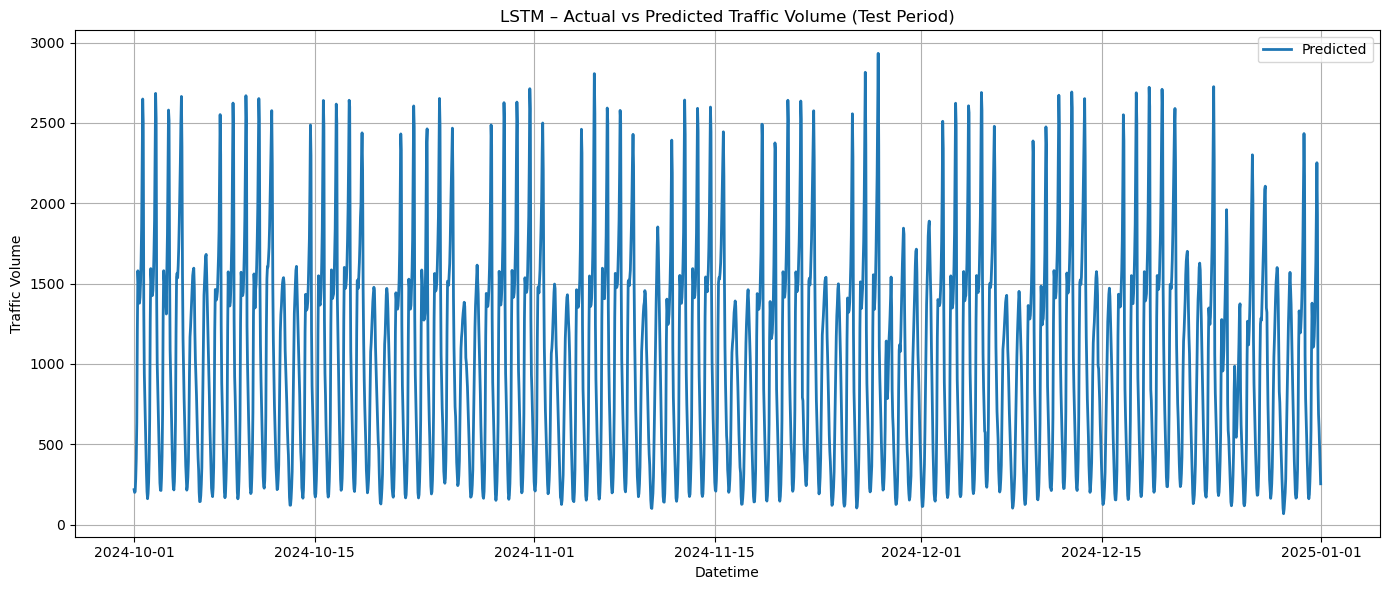

In [122]:
plt.figure(figsize=(14, 6))
# plt.plot(idx_test, y_test_inv, label="Actual", linewidth=2)
plt.plot(idx_test, y_pred_inv, label="Predicted", linewidth=2)
plt.title("LSTM – Actual vs Predicted Traffic Volume (Test Period)")
plt.xlabel("Datetime")
plt.ylabel("Traffic Volume")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [124]:
## Evaluate the model
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=False)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=False)
print("The training accuracy is:", train_acc)
print("The testing accuracy is:", test_acc)


TypeError: cannot unpack non-iterable float object